# HAM10000 — EfficientNet-B0 + ROI Segmentasyon + Optuna

**Pipeline:**
1. HAM10000 metadata yükleme (CSV)
2. Train/Val/Test split (stratified, lesion_id'ye göre — data leakage önlenir)
3. ROI segmentasyon (Otsu + morfoloji + contour)
4. ROI cache (npy) — Optuna trial'larında tekrar tekrar hesaplanmasın
5. EfficientNet-B0 (torchvision, ImageNet pretrained)
6. Optuna ile hiperparametre optimizasyonu (15 trial × 6 epoch — kısıtlı)
7. En iyi parametrelerle FULL eğitim (classifier → fine-tune)
8. Test + classification report + confusion matrix

In [1]:
# ============================================================
# 0. OPTUNA KURULUMU (Kaggle'da yok, internet açık olmalı)
# ============================================================
!pip install optuna --quiet

In [2]:
# ============================================================
# 1. KÜTÜPHANELER
# ============================================================
import os
import copy
import time
import random
import hashlib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms, models
from torchvision.models import EfficientNet_B0_Weights
from PIL import Image

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from pathlib import Path

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
# ============================================================
# 2. AYARLAR
# ============================================================
IMG_SIZE   = 224
SEED       = 42
VAL_SPLIT  = 0.15
TEST_SPLIT = 0.15

# HAM10000 path'leri (sizin notebook'unuza özel)
DATA_DIR     = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"
METADATA_CSV = os.path.join(DATA_DIR, "HAM10000_metadata.csv")
IMG_DIR_1    = os.path.join(DATA_DIR, "HAM10000_images_part_1")
IMG_DIR_2    = os.path.join(DATA_DIR, "HAM10000_images_part_2")

# Çıktı path'leri (Kaggle /kaggle/working/ kalıcı)
OUTPUT_DIR        = "/kaggle/working"
ROI_CACHE_DIR     = os.path.join(OUTPUT_DIR, "roi_cache")
MODEL_SAVE_PATH   = os.path.join(OUTPUT_DIR, "best_efficientnet_b0.pth")
PROBS_SAVE_PATH   = os.path.join(OUTPUT_DIR, "probabilities_efficientnet_b0.npy")
LABELS_SAVE_PATH  = os.path.join(OUTPUT_DIR, "test_labels_efficientnet_b0.npy")
CM_SAVE_PATH      = os.path.join(OUTPUT_DIR, "confusion_matrix_efficientnet_b0.jpg")
STUDY_SAVE_PATH   = os.path.join(OUTPUT_DIR, "optuna_study.pkl")

# 7 sınıf (HAM10000)
TARGET_CLASSES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
CLASS_FULL_NAMES = {
    'akiec': 'Actinic Keratoses',
    'bcc':   'Basal Cell Carcinoma',
    'bkl':   'Benign Keratosis',
    'df':    'Dermatofibroma',
    'mel':   'Melanoma',
    'nv':    'Melanocytic Nevi',
    'vasc':  'Vascular Lesions'
}

# Optuna kısıtlama (hocanın isteği)
OPTUNA_N_TRIALS  = 15
OPTUNA_EPOCHS    = 6   # Her trial için kısa eğitim

# Final eğitim
FINAL_EPOCHS     = 50  # classifier-only stage
FT_EPOCHS        = 30  # fine-tune stage
EARLY_STOP_PAT   = 12

print(f"IMG_SIZE: {IMG_SIZE}")
print(f"Sınıf sayısı: {len(TARGET_CLASSES)}")
print(f"Optuna: {OPTUNA_N_TRIALS} trial × {OPTUNA_EPOCHS} epoch")
print(f"Final: {FINAL_EPOCHS} epoch (classifier) + {FT_EPOCHS} epoch (fine-tune)")

IMG_SIZE: 224
Sınıf sayısı: 7
Optuna: 15 trial × 6 epoch
Final: 50 epoch (classifier) + 30 epoch (fine-tune)


In [4]:
# ============================================================
# 3. SEED
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

set_seed(SEED)

In [5]:
# ============================================================
# 4. DEVICE (CUDA / CPU)
# ============================================================
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Kullanılan cihaz: CUDA - {torch.cuda.get_device_name(0)}")
    free, total = torch.cuda.mem_get_info(0)
    print(f"VRAM: {total / 1024**3:.1f} GB")
else:
    device = torch.device("cpu")
    print("⚠️ CUDA bulunamadı! CPU kullanılacak.")

Kullanılan cihaz: CUDA - Tesla T4
VRAM: 14.6 GB


In [6]:
# ============================================================
# 5. METADATA YÜKLEME + IMAGE PATH EŞLEME
# ============================================================
df = pd.read_csv(METADATA_CSV)
print(f"Metadata satır sayısı: {len(df)}")
print(f"Sütunlar: {df.columns.tolist()}")

# Her image_id için tam path bul (part_1 veya part_2)
all_images = {}
for img_dir in [IMG_DIR_1, IMG_DIR_2]:
    if os.path.exists(img_dir):
        for fname in os.listdir(img_dir):
            if fname.lower().endswith('.jpg'):
                image_id = fname.replace('.jpg', '')
                all_images[image_id] = os.path.join(img_dir, fname)

print(f"\nBulunan toplam görüntü: {len(all_images)}")

df['image_path'] = df['image_id'].map(all_images)
missing = df['image_path'].isna().sum()
if missing > 0:
    print(f"⚠️ {missing} görüntünün path'i bulunamadı, kaldırılıyor.")
    df = df.dropna(subset=['image_path']).reset_index(drop=True)

# Sınıf indeksleri
class_to_idx = {cls: idx for idx, cls in enumerate(TARGET_CLASSES)}
df['label'] = df['dx'].map(class_to_idx)

print(f"\nFinal satır sayısı: {len(df)}")
print(f"\nSınıf dağılımı:")
for cls in TARGET_CLASSES:
    n = (df['dx'] == cls).sum()
    print(f"  {cls} ({CLASS_FULL_NAMES[cls]}): {n}")

Metadata satır sayısı: 10015
Sütunlar: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Bulunan toplam görüntü: 10015

Final satır sayısı: 10015

Sınıf dağılımı:
  akiec (Actinic Keratoses): 327
  bcc (Basal Cell Carcinoma): 514
  bkl (Benign Keratosis): 1099
  df (Dermatofibroma): 115
  mel (Melanoma): 1113
  nv (Melanocytic Nevi): 6705
  vasc (Vascular Lesions): 142


In [7]:
# ============================================================
# 6. TRAIN / VAL / TEST SPLIT
# Lesion_id bazında split — aynı lezyonun farklı görüntüleri
# train ve test'e dağılmasın (data leakage önleme).
# Stratified: sınıf oranları korunur.
# ============================================================
lesion_df = df.groupby('lesion_id').first().reset_index()[['lesion_id', 'dx']]

# Önce test ayır
trainval_lesions, test_lesions = train_test_split(
    lesion_df, test_size=TEST_SPLIT, stratify=lesion_df['dx'], random_state=SEED
)
# Train'den val ayır
val_ratio = VAL_SPLIT / (1 - TEST_SPLIT)
train_lesions, val_lesions = train_test_split(
    trainval_lesions, test_size=val_ratio, stratify=trainval_lesions['dx'], random_state=SEED
)

train_df = df[df['lesion_id'].isin(train_lesions['lesion_id'])].reset_index(drop=True)
val_df   = df[df['lesion_id'].isin(val_lesions['lesion_id'])].reset_index(drop=True)
test_df  = df[df['lesion_id'].isin(test_lesions['lesion_id'])].reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nTrain sınıf dağılımı:")
print(train_df['dx'].value_counts())
print(f"\nTest sınıf dağılımı:")
print(test_df['dx'].value_counts())

Train: 7054 | Val: 1464 | Test: 1497

Train sınıf dağılımı:
dx
nv       4730
mel       777
bkl       775
bcc       365
akiec     233
vasc       98
df         76
Name: count, dtype: int64

Test sınıf dağılımı:
dx
nv       1000
mel       168
bkl       157
bcc        77
akiec      51
df         22
vasc       22
Name: count, dtype: int64


In [8]:
# ============================================================
# 7. ROI (REGION OF INTEREST) FONKSİYONU
# Hocanın istediği segmentasyon: lezyonu Otsu + morfoloji ile
# segment edip bounding box ile crop ediyoruz.
# ============================================================
def extract_roi(image_path, target_size=224):
    """
    Görüntüden lezyon bölgesini (ROI) otomatik tespit eder ve kırpar.
    Adımlar:
      1. Grayscale + Gaussian blur
      2. Otsu thresholding (ters: lezyon koyu, arka plan açık)
      3. Morfolojik kapatma + açma (gürültü temizleme)
      4. En büyük kontur → bounding box
      5. %15 padding ile crop
      6. target_size'a resize
    """
    img = cv2.imread(image_path)
    if img is None:
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (11, 11), 0)

    _, thresh = cv2.threshold(
        blurred, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    if contours:
        largest = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest)
        img_area = img.shape[0] * img.shape[1]

        # Çok küçük veya çok büyük kontur → güvenilmez, tüm görüntüyü kullan
        if area < img_area * 0.01 or area > img_area * 0.95:
            roi = img_rgb
        else:
            x, y, w, h = cv2.boundingRect(largest)
            pad_x = int(w * 0.15)
            pad_y = int(h * 0.15)
            x1 = max(0, x - pad_x)
            y1 = max(0, y - pad_y)
            x2 = min(img.shape[1], x + w + pad_x)
            y2 = min(img.shape[0], y + h + pad_y)
            roi = img_rgb[y1:y2, x1:x2]
    else:
        roi = img_rgb

    roi = cv2.resize(roi, (target_size, target_size))
    return roi

In [9]:
# ============================================================
# 8. ROI CACHE
# Optuna 15 trial yapacak. Her trial'da 10K görüntü için ROI
# yeniden hesaplamak çok pahalı. Bir kez hesaplayıp .npy olarak
# cache'liyoruz, sonraki trial'lar diskten okuyor.
# ============================================================
Path(ROI_CACHE_DIR).mkdir(parents=True, exist_ok=True)

def get_cached_roi(image_path, target_size=224):
    key = hashlib.md5(image_path.encode()).hexdigest()
    cache_path = os.path.join(ROI_CACHE_DIR, f"{key}.npy")

    if os.path.exists(cache_path):
        return np.load(cache_path)

    roi = extract_roi(image_path, target_size)
    if roi is not None:
        np.save(cache_path, roi)
    return roi

print(f"ROI cache klasörü: {ROI_CACHE_DIR}")

ROI cache klasörü: /kaggle/working/roi_cache


In [10]:
# ============================================================
# 9. ROI CACHE'İ ÖNCEDEN OLUŞTUR (TÜM DATASET İÇİN)
# Bir kez yapılır, ~5-10 dakika sürer. Sonra Optuna ve final
# eğitim diskten hızlıca okuyacak.
# ============================================================
print("ROI cache oluşturuluyor (tüm dataset için, bir kez)...")
start = time.time()

fail_count = 0
for i, path in enumerate(df['image_path'].values):
    roi = get_cached_roi(path, IMG_SIZE)
    if roi is None:
        fail_count += 1
    if (i + 1) % 1000 == 0:
        elapsed = time.time() - start
        print(f"  {i+1}/{len(df)} - {elapsed:.1f}s geçti")

elapsed = time.time() - start
print(f"\nROI cache tamamlandı! Süre: {elapsed/60:.1f} dakika")
print(f"Hata sayısı: {fail_count}")

cache_size_mb = sum(
    os.path.getsize(os.path.join(ROI_CACHE_DIR, f))
    for f in os.listdir(ROI_CACHE_DIR)
) / 1024**2
print(f"Cache boyutu: {cache_size_mb:.1f} MB")

ROI cache oluşturuluyor (tüm dataset için, bir kez)...
  1000/10015 - 0.1s geçti
  2000/10015 - 0.3s geçti
  3000/10015 - 0.4s geçti
  4000/10015 - 0.6s geçti
  5000/10015 - 0.7s geçti
  6000/10015 - 0.9s geçti
  7000/10015 - 1.0s geçti
  8000/10015 - 1.2s geçti
  9000/10015 - 1.3s geçti
  10000/10015 - 1.4s geçti

ROI cache tamamlandı! Süre: 0.0 dakika
Hata sayısı: 0
Cache boyutu: 1438.9 MB


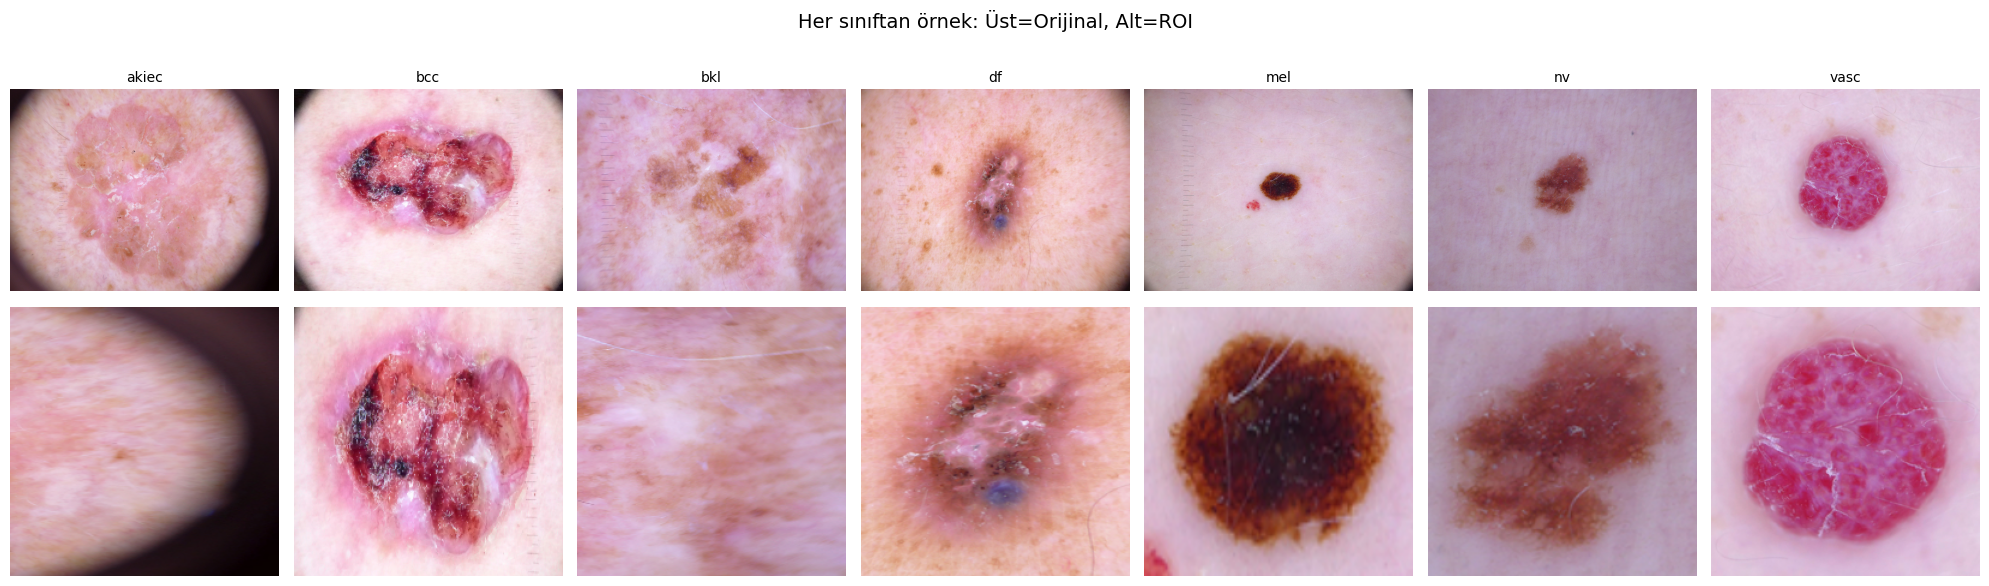

In [11]:
# ============================================================
# 10. ROI ÖRNEKLERİNİ GÖRSELLEŞTİR
# ============================================================
fig, axes = plt.subplots(2, 7, figsize=(20, 6))
fig.suptitle('Her sınıftan örnek: Üst=Orijinal, Alt=ROI', fontsize=14)

for col, cls in enumerate(TARGET_CLASSES):
    sample = df[df['dx'] == cls].iloc[0]
    img_path = sample['image_path']
    
    # Orijinal
    orig = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    axes[0, col].imshow(orig)
    axes[0, col].set_title(f"{cls}", fontsize=10)
    axes[0, col].axis('off')
    
    # ROI
    roi = get_cached_roi(img_path, IMG_SIZE)
    axes[1, col].imshow(roi)
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roi_examples.png'), dpi=100, bbox_inches='tight')
plt.show()

In [12]:
# ============================================================
# 11. DATASET SINIFI
# ROI'leri cache'ten okuyup transform uygular.
# ============================================================
class HAM10000ROIDataset(Dataset):
    def __init__(self, dataframe, transform=None, target_size=224):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['image_path']
        label = int(row['label'])

        try:
            roi = get_cached_roi(img_path, self.target_size)
            if roi is None:
                img = Image.open(img_path).convert('RGB').resize(
                    (self.target_size, self.target_size)
                )
            else:
                img = Image.fromarray(roi)

            if self.transform:
                img = self.transform(img)
            return img, label

        except Exception as e:
            print(f"Hata: {img_path} -> {e}")
            fallback = Image.new('RGB', (self.target_size, self.target_size), (0, 0, 0))
            if self.transform:
                fallback = self.transform(fallback)
            return fallback, label

In [13]:
# ============================================================
# 12. TRANSFORMS
# Train için augmentation, val/test için sadece normalize.
# ============================================================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomAffine(degrees=0, shear=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [14]:
# ============================================================
# 13. CLASS WEIGHTS (YUMUŞAK)
# v1'de class weights çok ekstremdi (df=13.26), Sampler ile birlikte
# çoğunluk sınıfı (nv) öğrenmeyi bıraktı.
# v2'de sqrt scaling ile yumuşatıyoruz, max=3 ile sınırlıyoruz.
# WeightedRandomSampler kaldırıldı (h15'te şuffle=True yapacağız).
# ============================================================
NUM_CLASSES = len(TARGET_CLASSES)
labels_train = train_df['label'].values
class_counts = np.bincount(labels_train, minlength=NUM_CLASSES)
total = len(labels_train)

# Klasik formül: total / (NUM_CLASSES * count) → çok sert
raw_weights = total / (NUM_CLASSES * class_counts)
# Sqrt yumuşatma + max 3 ile clip
soft_weights = np.sqrt(raw_weights)
soft_weights = np.clip(soft_weights, 0.5, 3.0)

class_weights = torch.tensor(soft_weights, dtype=torch.float32).to(device)

print("Class weights (yumuşatılmış):")
for i, cls in enumerate(TARGET_CLASSES):
    print(f"  {cls}: weight={class_weights[i]:.3f} (n={class_counts[i]}, raw={raw_weights[i]:.2f})")

Class weights (yumuşatılmış):
  akiec: weight=2.080 (n=233, raw=4.32)
  bcc: weight=1.662 (n=365, raw=2.76)
  bkl: weight=1.140 (n=775, raw=1.30)
  df: weight=3.000 (n=76, raw=13.26)
  mel: weight=1.139 (n=777, raw=1.30)
  nv: weight=0.500 (n=4730, raw=0.21)
  vasc: weight=3.000 (n=98, raw=10.28)


In [15]:
# ============================================================
# 14. DATALOADER YAPICI FONKSİYONU
# v2: WeightedRandomSampler KALDIRILDI. 
# Sadece class_weights ile loss'ta dengeleme.
# Sampler yerine standart shuffle=True.
# ============================================================
def make_loaders(batch_size, num_workers=2):
    train_ds = HAM10000ROIDataset(train_df, transform=train_transform, target_size=IMG_SIZE)
    val_ds   = HAM10000ROIDataset(val_df,   transform=eval_transform,  target_size=IMG_SIZE)
    test_ds  = HAM10000ROIDataset(test_df,  transform=eval_transform,  target_size=IMG_SIZE)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True
    )
    return train_loader, val_loader, test_loader

In [16]:
# ============================================================
# 15. EFFICIENTNET-B0 MODEL FONKSİYONU
# Optuna'nın denediği dropout için parametrik.
# ============================================================
def build_model(dropout=0.3, freeze_backbone=True):
    model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # EfficientNet-B0 son feature: 1280
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(dropout * 0.7),
        nn.Linear(512, NUM_CLASSES)
    )
    return model.to(device)

In [17]:
# ============================================================
# 16. TRAIN / EVAL FONKSİYONLARI
# v2: evaluate'a opsiyonel weighted_loss parametresi eklendi.
# Train'de class_weights kullanıyoruz, val/test'te kullanmıyoruz
# (loss değerlerinin yorumlanabilir olması için).
# ============================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device, return_preds=False):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []
    all_probs = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            loss = criterion(outputs, labels)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * images.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    # Macro F1 — dengeli, her sınıfa eşit ağırlık (azınlıkları doğru ölçer)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )
    if return_preds:
        return (running_loss/total, correct/total, precision, recall, f1,
                np.array(all_labels), np.array(all_preds), np.array(all_probs))
    return running_loss/total, correct/total, f1

In [18]:
# ============================================================
# 17. OPTUNA OBJECTIVE FONKSİYONU
# v2 değişiklikleri:
# - LR üst sınırı 1e-2 → 3e-3 (1e-2 çok büyüktü, model patlıyordu)
# - Val/test loss'unda class_weights yok (val_eval_criterion)
# - Macro F1 optimize ediliyor (azınlıkları da iyi öğrensin)
# ============================================================
def objective(trial):
    # KISITLI search space (v2 — daha realistik)
    lr           = trial.suggest_float('lr', 1e-4, 3e-3, log=True)
    dropout      = trial.suggest_float('dropout', 0.2, 0.5)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    batch_size   = trial.suggest_categorical('batch_size', [32, 64])

    train_loader, val_loader, _ = make_loaders(batch_size)
    
    model = build_model(dropout=dropout, freeze_backbone=True)
    
    # Train criterion: class_weights + label_smoothing
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    # Val criterion: clean (yorumlanabilir loss)
    val_criterion = nn.CrossEntropyLoss()
    
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    scheduler = CosineAnnealingLR(optimizer, T_max=OPTUNA_EPOCHS)

    best_val_f1 = 0.0
    for epoch in range(OPTUNA_EPOCHS):
        train_one_epoch(model, train_loader, criterion, optimizer, device)
        scheduler.step()
        _, val_acc, val_f1 = evaluate(model, val_loader, val_criterion, device)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1

        # Pruning
        trial.report(val_f1, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    del model, optimizer, scheduler
    torch.cuda.empty_cache()

    return best_val_f1

In [19]:
# ============================================================
# 18. OPTUNA STUDY ÇALIŞTIR
# TPESampler: Bayesian-style, random'dan akıllı
# MedianPruner: Medyan altında kalan trial'ları kes
# ============================================================
print("=" * 60)
print(f"OPTUNA HİPERPARAMETRE OPTİMİZASYONU")
print(f"Trial: {OPTUNA_N_TRIALS} | Epoch/trial: {OPTUNA_EPOCHS}")
print("=" * 60)

study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(n_startup_trials=3, n_warmup_steps=2)
)

study_start = time.time()
study.optimize(objective, n_trials=OPTUNA_N_TRIALS, show_progress_bar=True)
study_elapsed = (time.time() - study_start) / 60

print(f"\nOptuna tamamlandı! Süre: {study_elapsed:.1f} dakika")
print(f"\nEn iyi trial:")
print(f"  Val F1: {study.best_value:.4f}")
print(f"  Parametreler:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

OPTUNA HİPERPARAMETRE OPTİMİZASYONU
Trial: 15 | Epoch/trial: 6


  0%|          | 0/15 [00:00<?, ?it/s]

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth



  0%|          | 0.00/20.5M [00:00<?, ?B/s]
100%|██████████| 20.5M/20.5M [00:00<00:00, 134MB/s] 



Optuna tamamlandı! Süre: 51.9 dakika

En iyi trial:
  Val F1: 0.5568
  Parametreler:
    lr: 0.0004687600961225198
    dropout: 0.2116175599883549
    weight_decay: 3.486004913234137e-05
    batch_size: 64


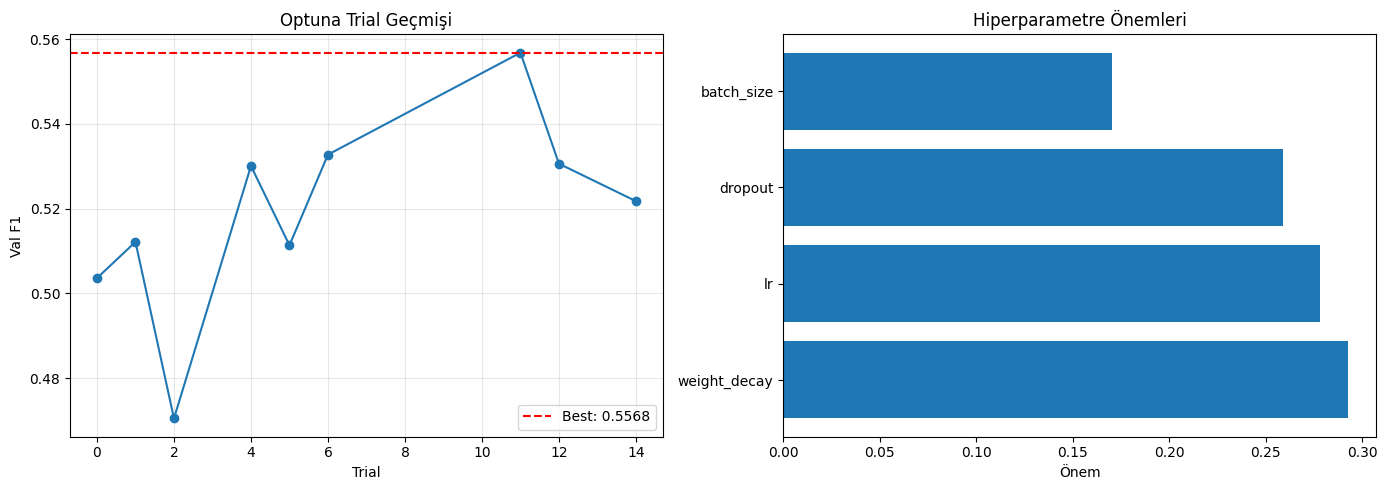

In [20]:
# ============================================================
# 19. OPTUNA SONUÇLARINI GÖRSELLEŞTİR
# ============================================================
import pickle
with open(STUDY_SAVE_PATH, 'wb') as f:
    pickle.dump(study, f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trial history
trials_df = study.trials_dataframe()
completed = trials_df[trials_df['state'] == 'COMPLETE']
axes[0].plot(completed['number'], completed['value'], 'o-')
axes[0].axhline(y=study.best_value, color='r', linestyle='--', label=f'Best: {study.best_value:.4f}')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Val F1')
axes[0].set_title('Optuna Trial Geçmişi')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Param importances
try:
    importances = optuna.importance.get_param_importances(study)
    params_list = list(importances.keys())
    values_list = list(importances.values())
    axes[1].barh(params_list, values_list)
    axes[1].set_xlabel('Önem')
    axes[1].set_title('Hiperparametre Önemleri')
except Exception as e:
    axes[1].text(0.5, 0.5, f'Hesaplanamadı:\n{e}', ha='center', va='center')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'optuna_results.png'), dpi=100, bbox_inches='tight')
plt.show()

In [21]:
# ============================================================
# 20. EN İYİ PARAMETRELERLE FİNAL EĞİTİM - AŞAMA 1: CLASSIFIER
# v2: val_criterion ayrı (class_weights'siz)
# ============================================================
best_params = study.best_params
BEST_LR     = best_params['lr']
BEST_DROP   = best_params['dropout']
BEST_WD     = best_params['weight_decay']
BEST_BS     = best_params['batch_size']

print("=" * 60)
print("FİNAL EĞİTİM - AŞAMA 1: CLASSIFIER (Backbone donuk)")
print(f"LR={BEST_LR:.5f} | Dropout={BEST_DROP:.3f} | WD={BEST_WD:.5f} | BS={BEST_BS}")
print("=" * 60)

train_loader, val_loader, test_loader = make_loaders(BEST_BS)

model = build_model(dropout=BEST_DROP, freeze_backbone=True)
# Train criterion: class_weights ile
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
# Val/test criterion: temiz (yorumlanabilir loss)
val_criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=BEST_LR, weight_decay=BEST_WD
)
scheduler = CosineAnnealingLR(optimizer, T_max=FINAL_EPOCHS)

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
epochs_no_improve = 0

stage1_start = time.time()

for epoch in range(FINAL_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader, val_criterion, device)
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{FINAL_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f} | "
          f"LR: {current_lr:.6f}", end='')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        epochs_no_improve = 0
        print(" ✅")
    else:
        epochs_no_improve += 1
        print(f" (no improve {epochs_no_improve}/{EARLY_STOP_PAT})")

    if epochs_no_improve >= EARLY_STOP_PAT:
        print("⛔ Early stopping!")
        break

stage1_elapsed = (time.time() - stage1_start) / 60
print(f"\nAşama 1 süresi: {stage1_elapsed:.1f} dakika | Best Val Acc: {best_val_acc:.4f}")

FİNAL EĞİTİM - AŞAMA 1: CLASSIFIER (Backbone donuk)
LR=0.00047 | Dropout=0.212 | WD=0.00003 | BS=64
Epoch 1/50 | Train Loss: 1.7922 Acc: 0.6317 | Val Loss: 0.9888 Acc: 0.7022 F1: 0.4434 | LR: 0.000468 ✅
Epoch 2/50 | Train Loss: 1.6789 Acc: 0.6873 | Val Loss: 0.9182 Acc: 0.7206 F1: 0.4579 | LR: 0.000467 ✅
Epoch 3/50 | Train Loss: 1.6447 Acc: 0.7014 | Val Loss: 0.9397 Acc: 0.7220 F1: 0.4978 | LR: 0.000465 ✅
Epoch 4/50 | Train Loss: 1.6086 Acc: 0.7046 | Val Loss: 0.8921 Acc: 0.7391 F1: 0.5029 | LR: 0.000461 ✅
Epoch 5/50 | Train Loss: 1.6013 Acc: 0.7053 | Val Loss: 0.9133 Acc: 0.7172 F1: 0.4872 | LR: 0.000457 (no improve 1/12)
Epoch 6/50 | Train Loss: 1.6008 Acc: 0.7129 | Val Loss: 0.9338 Acc: 0.7240 F1: 0.5066 | LR: 0.000452 (no improve 2/12)
Epoch 7/50 | Train Loss: 1.5752 Acc: 0.7272 | Val Loss: 0.9275 Acc: 0.7111 F1: 0.5075 | LR: 0.000446 (no improve 3/12)
Epoch 8/50 | Train Loss: 1.5703 Acc: 0.7204 | Val Loss: 0.9030 Acc: 0.7220 F1: 0.5039 | LR: 0.000440 (no improve 4/12)
Epoch 9/50 |

In [22]:
# ============================================================
# 21. AŞAMA 1 TEST DEĞERLENDİRMESİ
# v2: test_criterion temiz (class_weights yok)
# ============================================================
model.load_state_dict(best_model_wts)
test_criterion = nn.CrossEntropyLoss()
phase1_loss, phase1_acc, phase1_prec, phase1_rec, phase1_f1, _, _, _ = evaluate(
    model, test_loader, test_criterion, device, return_preds=True
)

print("=" * 60)
print("AŞAMA 1 TEST SONUÇLARI (Sadece Classifier)")
print("=" * 60)
print(f"Test Loss     : {phase1_loss:.4f}")
print(f"Test Accuracy : {phase1_acc:.4f}")
print(f"Test Precision (macro): {phase1_prec:.4f}")
print(f"Test Recall    (macro): {phase1_rec:.4f}")
print(f"Test F1        (macro): {phase1_f1:.4f}")

AŞAMA 1 TEST SONUÇLARI (Sadece Classifier)
Test Loss     : 0.8599
Test Accuracy : 0.7555
Test Precision (macro): 0.5794
Test Recall    (macro): 0.5680
Test F1        (macro): 0.5686


In [23]:
# ============================================================
# 22. AŞAMA 2: FINE-TUNING
# v2: val_criterion ayrı
# ============================================================
print("=" * 60)
print("AŞAMA 2: FINE-TUNING")
print("=" * 60)

for name, param in model.named_parameters():
    if any(x in name for x in ['features.6', 'features.7', 'features.8', 'classifier']):
        param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Eğitilebilir: {trainable:,} / {total_params:,} ({100*trainable/total_params:.1f}%)")

FT_LR = BEST_LR / 10

backbone_params = []
classifier_params = []
for name, param in model.named_parameters():
    if param.requires_grad:
        if 'classifier' in name:
            classifier_params.append(param)
        else:
            backbone_params.append(param)

optimizer_ft = optim.AdamW([
    {'params': backbone_params, 'lr': FT_LR / 5},
    {'params': classifier_params, 'lr': FT_LR}
], weight_decay=BEST_WD)
scheduler_ft = CosineAnnealingLR(optimizer_ft, T_max=FT_EPOCHS)

best_ft_acc = phase1_acc
best_ft_wts = copy.deepcopy(model.state_dict())
ft_no_improve = 0

ft_start = time.time()

for epoch in range(FT_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer_ft, device)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader, val_criterion, device)
    scheduler_ft.step()
    current_lr = optimizer_ft.param_groups[0]['lr']

    print(f"FT Epoch {epoch+1}/{FT_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f} | "
          f"LR: {current_lr:.6f}", end='')

    if val_acc > best_ft_acc:
        best_ft_acc = val_acc
        best_ft_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        ft_no_improve = 0
        print(" ✅")
    else:
        ft_no_improve += 1
        print(f" (no improve {ft_no_improve}/{EARLY_STOP_PAT})")

    if ft_no_improve >= EARLY_STOP_PAT:
        print("⛔ Fine-tuning early stopping!")
        break

ft_elapsed = (time.time() - ft_start) / 60
print(f"\nAşama 2 süresi: {ft_elapsed:.1f} dakika | Best Val Acc: {best_ft_acc:.4f}")

AŞAMA 2: FINE-TUNING
Eğitilebilir: 3,816,227 / 4,668,035 (81.8%)
FT Epoch 1/30 | Train Loss: 1.4961 Acc: 0.7553 | Val Loss: 0.8598 Acc: 0.7534 F1: 0.5647 | LR: 0.000009 (no improve 1/12)
FT Epoch 2/30 | Train Loss: 1.4864 Acc: 0.7526 | Val Loss: 0.8525 Acc: 0.7480 F1: 0.5490 | LR: 0.000009 (no improve 2/12)
FT Epoch 3/30 | Train Loss: 1.4671 Acc: 0.7667 | Val Loss: 0.8496 Acc: 0.7520 F1: 0.5667 | LR: 0.000009 (no improve 3/12)
FT Epoch 4/30 | Train Loss: 1.4609 Acc: 0.7625 | Val Loss: 0.8528 Acc: 0.7500 F1: 0.5756 | LR: 0.000009 (no improve 4/12)
FT Epoch 5/30 | Train Loss: 1.4531 Acc: 0.7613 | Val Loss: 0.8556 Acc: 0.7500 F1: 0.5675 | LR: 0.000009 (no improve 5/12)
FT Epoch 6/30 | Train Loss: 1.4478 Acc: 0.7702 | Val Loss: 0.8332 Acc: 0.7582 F1: 0.5665 | LR: 0.000008 ✅
FT Epoch 7/30 | Train Loss: 1.4325 Acc: 0.7828 | Val Loss: 0.8260 Acc: 0.7575 F1: 0.5707 | LR: 0.000008 (no improve 1/12)
FT Epoch 8/30 | Train Loss: 1.4276 Acc: 0.7814 | Val Loss: 0.8373 Acc: 0.7575 F1: 0.5675 | LR: 0.

In [24]:
# ============================================================
# 23. FINAL TEST DEĞERLENDİRMESİ
# ============================================================
model.load_state_dict(best_ft_wts)
test_loss, test_acc, test_prec, test_rec, test_f1, y_true, y_pred, y_probs = evaluate(
    model, test_loader, test_criterion, device, return_preds=True
)

print("=" * 60)
print("FİNAL TEST SONUÇLARI - EfficientNet-B0 + ROI + Optuna (v2)")
print("=" * 60)
print(f"Test Loss             : {test_loss:.4f}")
print(f"Test Accuracy         : {test_acc:.4f}")
print(f"Test Precision (macro): {test_prec:.4f}")
print(f"Test Recall    (macro): {test_rec:.4f}")
print(f"Test F1        (macro): {test_f1:.4f}")

print("\n--- KARŞILAŞTIRMA ---")
print(f"Aşama 1 (Classifier only) Acc: {phase1_acc:.4f}")
print(f"Aşama 2 (Fine-tuned)      Acc: {test_acc:.4f}")
print(f"İyileşme: {(test_acc - phase1_acc)*100:+.2f} puan")

if device.type == 'cuda':
    print(f"\nMax VRAM kullanımı: {torch.cuda.max_memory_allocated()/1024**2:.0f} MB")

FİNAL TEST SONUÇLARI - EfficientNet-B0 + ROI + Optuna (v2)
Test Loss             : 0.8255
Test Accuracy         : 0.7682
Test Precision (macro): 0.5742
Test Recall    (macro): 0.6034
Test F1        (macro): 0.5869

--- KARŞILAŞTIRMA ---
Aşama 1 (Classifier only) Acc: 0.7555
Aşama 2 (Fine-tuned)      Acc: 0.7682
İyileşme: +1.27 puan

Max VRAM kullanımı: 818 MB


In [25]:
# ============================================================
# 24. CLASSIFICATION REPORT
# ============================================================
print("\nClassification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=TARGET_CLASSES,
    digits=3, zero_division=0
))


Classification Report:
              precision    recall  f1-score   support

       akiec      0.434     0.451     0.442        51
         bcc      0.578     0.623     0.600        77
         bkl      0.526     0.580     0.552       157
          df      0.296     0.364     0.327        22
         mel      0.500     0.619     0.553       168
          nv      0.923     0.860     0.890      1000
        vasc      0.762     0.727     0.744        22

    accuracy                          0.768      1497
   macro avg      0.574     0.603     0.587      1497
weighted avg      0.788     0.768     0.776      1497



In [26]:
# ============================================================
# 25. NPY DOSYALARINI KAYDET
# ============================================================
np.save(PROBS_SAVE_PATH, y_probs)
np.save(LABELS_SAVE_PATH, y_true)
print(f"Probabilities: {PROBS_SAVE_PATH} | shape: {y_probs.shape}")
print(f"Labels: {LABELS_SAVE_PATH} | shape: {y_true.shape}")

Probabilities: /kaggle/working/probabilities_efficientnet_b0.npy | shape: (1497, 7)
Labels: /kaggle/working/test_labels_efficientnet_b0.npy | shape: (1497,)


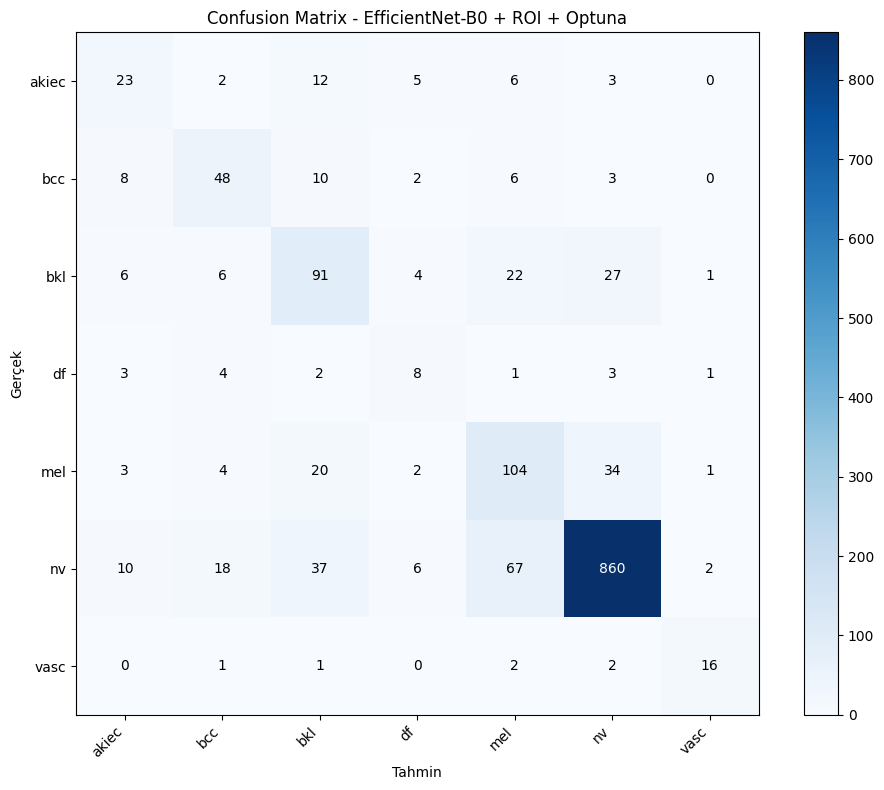

Kaydedildi: /kaggle/working/confusion_matrix_efficientnet_b0.jpg


In [27]:
# ============================================================
# 26. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - EfficientNet-B0 + ROI + Optuna')
plt.colorbar()

plt.xticks(range(NUM_CLASSES), TARGET_CLASSES, rotation=45, ha='right', fontsize=10)
plt.yticks(range(NUM_CLASSES), TARGET_CLASSES, fontsize=10)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=10)

plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.tight_layout()
plt.savefig(CM_SAVE_PATH, dpi=150, bbox_inches='tight')
plt.show()

print(f"Kaydedildi: {CM_SAVE_PATH}")

In [28]:
# ============================================================
# 27. ÖZET
# ============================================================
print("=" * 60)
print("PROJE TAMAMLANDI")
print("=" * 60)
print(f"Model: EfficientNet-B0")
print(f"Pipeline: ROI Segmentasyon + Optuna HPO + Fine-tuning")
print(f"Sınıf sayısı: {NUM_CLASSES}")
print(f"\nOptuna en iyi parametreler:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print(f"\nFinal Test Accuracy: {test_acc:.4f}")
print(f"Final Test F1: {test_f1:.4f}")
print(f"\nKaydedilen dosyalar:")
print(f"  Model       : {MODEL_SAVE_PATH}")
print(f"  Probs       : {PROBS_SAVE_PATH}")
print(f"  Labels      : {LABELS_SAVE_PATH}")
print(f"  CM          : {CM_SAVE_PATH}")
print(f"  Optuna study: {STUDY_SAVE_PATH}")

PROJE TAMAMLANDI
Model: EfficientNet-B0
Pipeline: ROI Segmentasyon + Optuna HPO + Fine-tuning
Sınıf sayısı: 7

Optuna en iyi parametreler:
  lr: 0.0004687600961225198
  dropout: 0.2116175599883549
  weight_decay: 3.486004913234137e-05
  batch_size: 64

Final Test Accuracy: 0.7682
Final Test F1: 0.5869

Kaydedilen dosyalar:
  Model       : /kaggle/working/best_efficientnet_b0.pth
  Probs       : /kaggle/working/probabilities_efficientnet_b0.npy
  Labels      : /kaggle/working/test_labels_efficientnet_b0.npy
  CM          : /kaggle/working/confusion_matrix_efficientnet_b0.jpg
  Optuna study: /kaggle/working/optuna_study.pkl
